# ❤️ Stage 4: Heart Disease Detector
### ML Roadmap — Classification Project


## Step 0: Install & Import Libraries

In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — classification toolkit
from sklearn.model_selection   import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier, plot_tree
from sklearn.ensemble          import RandomForestClassifier
from sklearn.preprocessing     import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.metrics           import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

print('✅ All libraries imported')
import sklearn; print(f'   Scikit-learn: {sklearn.__version__}')

✅ All libraries imported
   Scikit-learn: 1.8.0


---
## Step 1: Generate & Load the Dataset

Based on the **Cleveland Heart Disease dataset** structure (UCI Repository).  
Features are standard clinical measurements: age, blood pressure, cholesterol, ECG results, and more.

In [3]:
def generate_heart_disease_dataset(n=1200, seed=42):
    """
    Generate a realistic heart disease dataset.
    Mirrors the Cleveland Heart Disease dataset structure (UCI Repository).

    Features:
      age      : Patient age in years
      sex      : 1=Male, 0=Female
      cp       : Chest pain type (0=typical angina, 1=atypical, 2=non-anginal, 3=asymptomatic)
      trestbps : Resting blood pressure (mmHg)
      chol     : Serum cholesterol (mg/dL)
      fbs      : Fasting blood sugar > 120 mg/dL (1=True, 0=False)
      restecg  : Resting ECG results (0=normal, 1=ST-T abnormality, 2=LV hypertrophy)
      thalach  : Maximum heart rate achieved
      exang    : Exercise induced angina (1=Yes, 0=No)
      oldpeak  : ST depression induced by exercise relative to rest
      slope    : Slope of peak exercise ST segment (0=upsloping, 1=flat, 2=downsloping)
      ca       : Number of major vessels coloured by fluoroscopy (0-4)
      thal     : Thalassemia type (0=normal, 1=fixed defect, 2=normal flow, 3=reversible defect)
    """
    np.random.seed(seed)

    age      = np.clip(np.random.normal(54, 9, n), 29, 77).round(0).astype(int)
    sex      = np.random.choice([0,1], n, p=[0.32, 0.68])
    cp       = np.random.choice([0,1,2,3], n, p=[0.08, 0.17, 0.28, 0.47])
    trestbps = np.clip(np.random.normal(131, 17, n), 94, 200).round(0).astype(int)
    chol     = np.clip(np.random.normal(246, 51, n), 126, 564).round(0).astype(int)
    fbs      = np.random.choice([0,1], n, p=[0.85, 0.15])
    restecg  = np.random.choice([0,1,2], n, p=[0.50, 0.48, 0.02])
    thalach  = np.clip(np.random.normal(149, 22, n), 71, 202).round(0).astype(int)
    exang    = np.random.choice([0,1], n, p=[0.67, 0.33])
    oldpeak  = np.clip(np.random.exponential(1.0, n), 0, 6.2).round(1)
    slope    = np.random.choice([0,1,2], n, p=[0.07, 0.46, 0.47])
    ca       = np.random.choice([0,1,2,3,4], n, p=[0.58, 0.22, 0.12, 0.06, 0.02])
    thal     = np.random.choice([0,1,2,3], n, p=[0.005, 0.055, 0.72, 0.22])

    # Risk score — clinically motivated formula
    risk_score = (
        (age - 40)*0.04 + sex*0.6
        + (cp==3)*1.5 + (cp==2)*0.8
        + (trestbps - 120)*0.015
        + (chol - 200)*0.003
        + fbs*0.4 + exang*1.0
        + oldpeak*0.4
        + (ca>0)*0.9 + (ca>1)*0.5
        + (thal==2)*(-0.8) + (thal==3)*0.7
        + (slope==0)*0.6
        + np.random.normal(0, 0.5, n)
    )
    prob   = 1 / (1 + np.exp(-risk_score + 3.0))
    target = (prob > 0.5).astype(int)

    df = pd.DataFrame({
        'age':age,'sex':sex,'cp':cp,'trestbps':trestbps,'chol':chol,
        'fbs':fbs,'restecg':restecg,'thalach':thalach,'exang':exang,
        'oldpeak':oldpeak,'slope':slope,'ca':ca,'thal':thal,'target':target
    })

    # Inject 3% realistic missing values
    for col in ['thal','ca','chol']:
        idx = np.random.choice(df.index, int(n*0.03), replace=False)
        df.loc[idx, col] = np.nan

    return df


# df = generate_heart_disease_dataset(n=1200)
# df.to_csv('heart_disease.csv', index=False)

# OR load from the provided CSV:
df = pd.read_csv('heart_disease.csv')

pos = (df['target']==1).sum(); neg = (df['target']==0).sum()
print(f'✅ Dataset loaded: {df.shape[0]:,} patients × {df.shape[1]} features')
print(f'   Heart Disease : {pos} patients ({pos/len(df)*100:.1f}%)')
print(f'   No Disease    : {neg} patients ({neg/len(df)*100:.1f}%)')
df.head()

✅ Dataset loaded: 1,200 patients × 14 features
   Heart Disease : 629 patients (52.4%)
   No Disease    : 571 patients (47.6%)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,58,0,3,123,245.000,0,0,153,0,0.300,1,0.000,3.000,1
1,53,1,3,121,241.000,0,0,115,1,0.100,2,0.000,2.000,0
2,60,1,2,139,308.000,0,0,150,0,0.100,1,NaN,2.000,0
3,68,1,3,125,191.000,0,0,118,0,0.400,2,0.000,2.000,0
4,52,1,2,129,207.000,0,0,159,1,1.400,2,1.000,2.000,1


---
## Step 2: Feature Definitions & Data Overview

Know what each feature means before you touch the data. This is clinical domain knowledge.

In [4]:
FEATURE_GUIDE = {
    'age'     : 'Patient age in years',
    'sex'     : 'Sex — 1=Male, 0=Female',
    'cp'      : 'Chest pain type — 0=Typical Angina, 1=Atypical, 2=Non-Anginal, 3=Asymptomatic',
    'trestbps': 'Resting blood pressure (mmHg) at hospital admission',
    'chol'    : 'Serum cholesterol (mg/dL)',
    'fbs'     : 'Fasting blood sugar > 120 mg/dL — 1=True, 0=False',
    'restecg' : 'Resting ECG — 0=Normal, 1=ST-T wave abnormality, 2=LV hypertrophy',
    'thalach' : 'Maximum heart rate achieved during stress test',
    'exang'   : 'Exercise-induced angina — 1=Yes, 0=No',
    'oldpeak' : 'ST depression induced by exercise relative to rest',
    'slope'   : 'Slope of peak exercise ST segment — 0=Up, 1=Flat, 2=Down',
    'ca'      : 'Number of major vessels coloured by fluoroscopy (0-4)',
    'thal'    : 'Thalassemia — 0=Normal, 1=Fixed Defect, 2=Normal Flow, 3=Reversible Defect',
    'target'  : '⭐ TARGET — 1=Heart Disease, 0=No Disease'
}

print('📋 Feature Guide:')
print('─'*65)
for feat, desc in FEATURE_GUIDE.items():
    print(f'  {feat:<10}: {desc}')

print('\n📊 Missing Value Report:')
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
audit = pd.DataFrame({'Missing':miss,'Missing%':miss_pct,'dtype':df.dtypes})
print(audit[audit['Missing']>0].to_string())

📋 Feature Guide:
─────────────────────────────────────────────────────────────────
  age       : Patient age in years
  sex       : Sex — 1=Male, 0=Female
  cp        : Chest pain type — 0=Typical Angina, 1=Atypical, 2=Non-Anginal, 3=Asymptomatic
  trestbps  : Resting blood pressure (mmHg) at hospital admission
  chol      : Serum cholesterol (mg/dL)
  fbs       : Fasting blood sugar > 120 mg/dL — 1=True, 0=False
  restecg   : Resting ECG — 0=Normal, 1=ST-T wave abnormality, 2=LV hypertrophy
  thalach   : Maximum heart rate achieved during stress test
  exang     : Exercise-induced angina — 1=Yes, 0=No
  oldpeak   : ST depression induced by exercise relative to rest
  slope     : Slope of peak exercise ST segment — 0=Up, 1=Flat, 2=Down
  ca        : Number of major vessels coloured by fluoroscopy (0-4)
  thal      : Thalassemia — 0=Normal, 1=Fixed Defect, 2=Normal Flow, 3=Reversible Defect
  target    : ⭐ TARGET — 1=Heart Disease, 0=No Disease

📊 Missing Value Report:
      Missing  Mi

In [5]:
print('📊 Numeric Summary:')
df.describe().round(2)

📊 Numeric Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1200.000,1200.000,1200.000,1200.000,1164.000,1200.000,1200.000,1200.000,1200.000,1200.000,1200.000,1164.000,1164.000,1200.000
mean,54.340,0.680,2.140,130.480,244.370,0.140,0.510,149.220,0.350,0.990,1.380,0.700,2.150,0.520
std,8.840,0.470,0.980,17.130,49.310,0.350,0.530,22.730,0.480,1.020,0.620,1.000,0.530,0.500
min,29.000,0.000,0.000,94.000,126.000,0.000,0.000,71.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,48.000,0.000,1.000,118.000,211.750,0.000,0.000,134.000,0.000,0.300,1.000,0.000,2.000,0.000
50%,54.000,1.000,2.000,130.000,245.000,0.000,0.000,149.000,0.000,0.700,1.000,0.000,2.000,1.000
75%,60.000,1.000,3.000,142.000,279.000,0.000,1.000,165.000,1.000,1.300,2.000,1.000,2.000,1.000
max,77.000,1.000,3.000,186.000,405.000,1.000,2.000,202.000,1.000,6.200,2.000,4.000,3.000,1.000


---
## Step 3: Exploratory Data Analysis


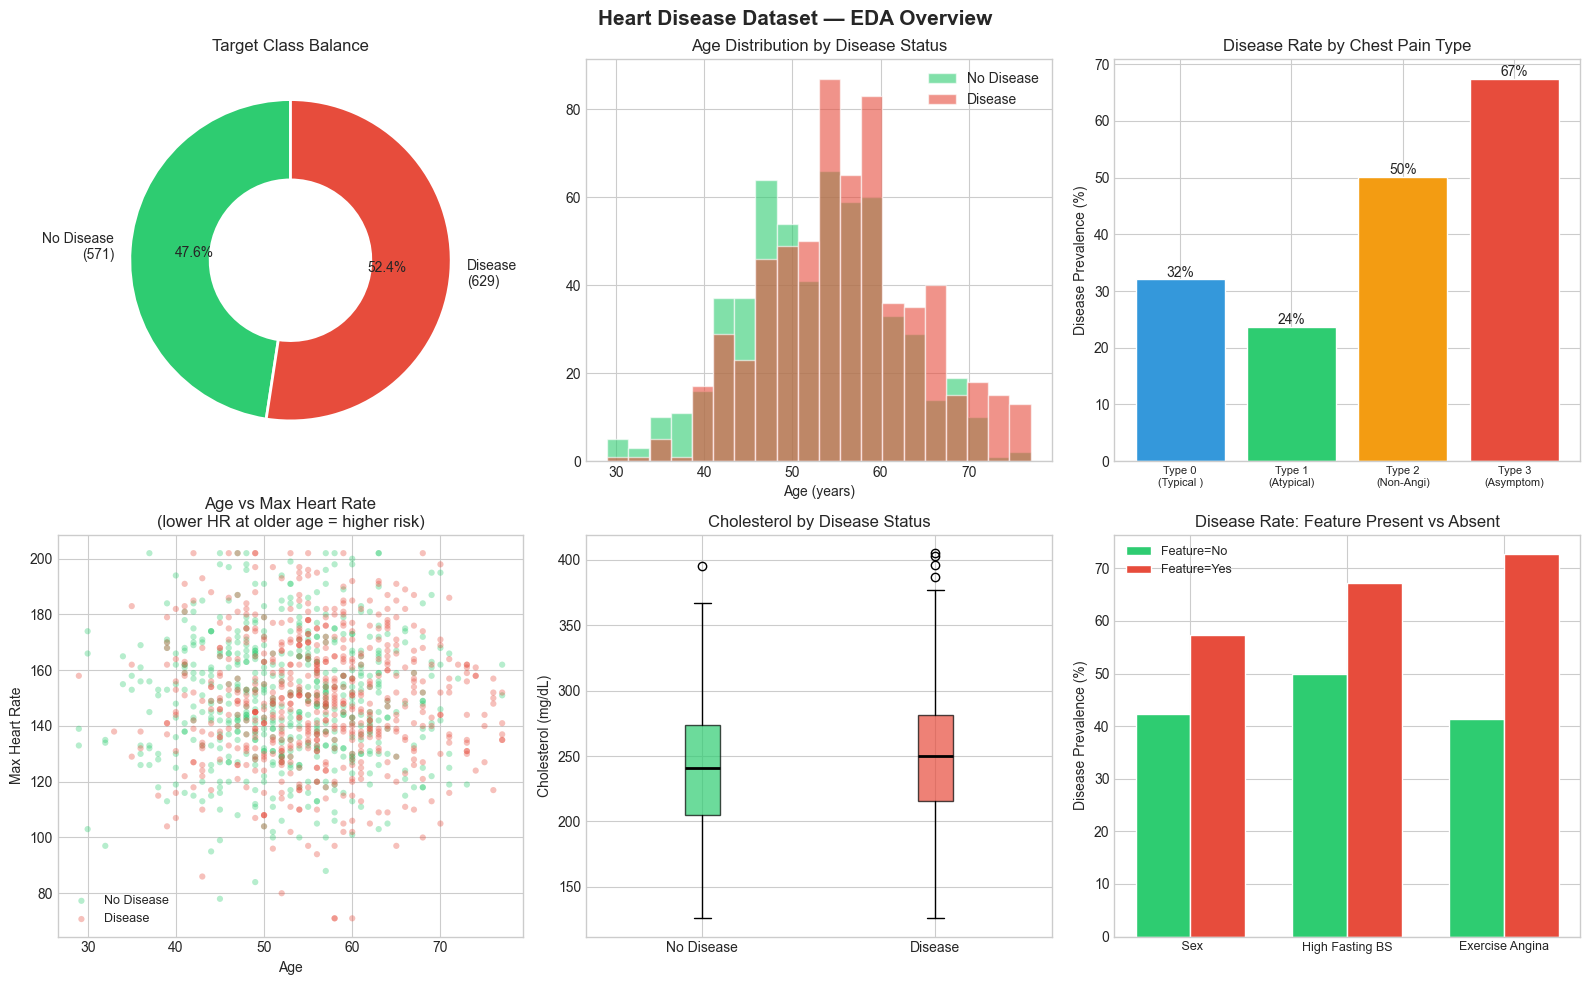

💾 Saved: hd_01_eda_overview.png


In [ ]:


CP_MAP   = {0:'Typical Angina', 1:'Atypical Angina', 2:'Non-Anginal', 3:'Asymptomatic'}
THAL_MAP = {0:'Normal', 1:'Fixed Defect', 2:'Normal Flow', 3:'Reversible Defect'} #இது blood flow / thalassemia test result.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Heart Disease Dataset — EDA Overview', fontsize=15, fontweight='bold')

# 1. Class balance donut - class Balanced dataset என்றால் model bias குறையும்.
# no disease = 0; vs disease = 1; ratio
counts = df['target'].value_counts().sort_index()
labels = [f'No Disease\n({counts[0]})', f'Disease\n({counts[1]})']
axes[0,0].pie(counts.values, labels=labels, autopct='%1.1f%%',
              colors=['#2ecc71','#e74c3c'],
              wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2), startangle=90)
axes[0,0].set_title('Target Class Balance')

# 2. Age distribution by target
for t, c, l in [(0,'#2ecc71','No Disease'),(1,'#e74c3c','Disease')]:
    axes[0,1].hist(df[df['target']==t]['age'], bins=20, alpha=0.6,
                   color=c, edgecolor='white', label=l)
axes[0,1].set_title('Age Distribution by Disease Status')
axes[0,1].set_xlabel('Age (years)'); axes[0,1].legend()

# 3. Chest pain type vs disease rate => Disease Prevalence (%) : இதன் meaning: அந்த group-ல் disease உள்ளவர்களின் percentage.
cp_disease = df.groupby('cp')['target'].mean() * 100
bars = axes[0,2].bar(range(len(cp_disease)), cp_disease.values,
                     color=['#3498db','#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
axes[0,2].set_xticks(range(len(cp_disease)))
axes[0,2].set_xticklabels([f'Type {i}\n({CP_MAP[i][:8]})' for i in cp_disease.index], fontsize=8)
axes[0,2].set_title('Disease Rate by Chest Pain Type')
axes[0,2].set_ylabel('Disease Prevalence (%)')
for bar, v in zip(bars, cp_disease.values):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.0f}%', ha='center', fontsize=10)

# 4. Age vs Max Heart Rate (scatter by target)
for t, c, l in [(0,'#2ecc71','No Disease'),(1,'#e74c3c','Disease')]:
    mask = df['target'] == t
    axes[1,0].scatter(df.loc[mask,'age'], df.loc[mask,'thalach'],
                      alpha=0.35, s=20, c=c, edgecolors='none', label=l)
axes[1,0].set_title('Age vs Max Heart Rate\n(lower HR at older age = higher risk)')
axes[1,0].set_xlabel('Age'); axes[1,0].set_ylabel('Max Heart Rate'); axes[1,0].legend(fontsize=9)

# 5. Cholesterol boxplot
df_c = df.dropna(subset=['chol'])
bp = axes[1,1].boxplot(
    [df_c[df_c['target']==0]['chol'], df_c[df_c['target']==1]['chol']],
    labels=['No Disease','Disease'], patch_artist=True,
    medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], ['#2ecc71','#e74c3c']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1,1].set_title('Cholesterol by Disease Status'); axes[1,1].set_ylabel('Cholesterol (mg/dL)')

# 6. Binary feature disease rates
bin_feats = ['sex','fbs','exang']
bin_names = [' Sex','High Fasting BS','Exercise Angina']
x = np.arange(len(bin_feats)); w = 0.35
no_d  = [df[df[f]==0]['target'].mean()*100 for f in bin_feats]
yes_d = [df[df[f]==1]['target'].mean()*100 for f in bin_feats]
axes[1,2].bar(x-w/2, no_d,  w, label='Feature=No',  color='#2ecc71', edgecolor='white') # Female patients.
axes[1,2].bar(x+w/2, yes_d, w, label='Feature=Yes', color='#e74c3c', edgecolor='white') # Male patients.
axes[1,2].set_xticks(x); axes[1,2].set_xticklabels(bin_names, fontsize=9)
axes[1,2].set_title('Disease Rate: Feature Present vs Absent')
axes[1,2].set_ylabel('Disease Prevalence (%)'); axes[1,2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('hd_01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show(); print('💾 Saved: hd_01_eda_overview.png')

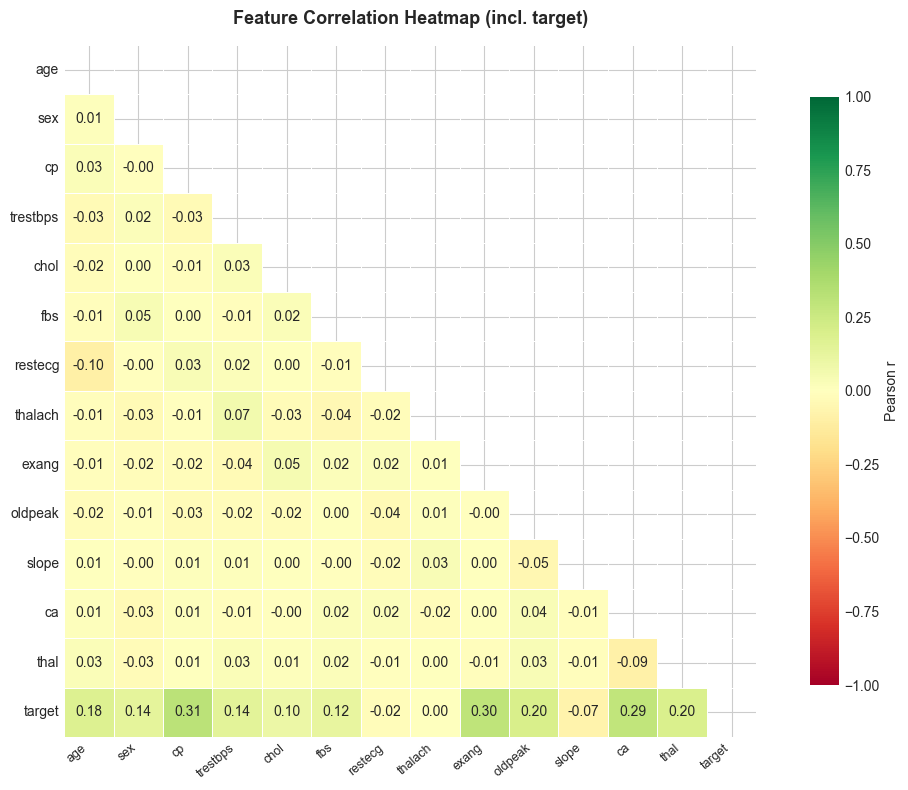

🔗 Feature correlation with target (heart disease):
cp          0.314
exang       0.301
ca          0.293
oldpeak     0.197
thal        0.195
age         0.176
trestbps    0.143
sex         0.140
fbs         0.120
chol        0.098
slope      -0.071
restecg    -0.021
thalach     0.004


In [8]:
# Correlation heatmap
corr = df.corr(numeric_only=True).round(3)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.6, linecolor='white',
            square=True, cbar_kws={'label':'Pearson r', 'shrink':0.85})
plt.title('Feature Correlation Heatmap (incl. target)', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('hd_02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Strongest correlations with target
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print('🔗 Feature correlation with target (heart disease):')
print(target_corr.to_string())

---
## Step 4: Feature Engineering

In [ ]:
df_model = df.copy()

# Age group (clinical standard risk bands)
df_model['age_group'] = pd.cut(df_model['age'],
    bins=[0, 40, 50, 60, 100],
    labels=['<40', '40-50', '50-60', '>60']).astype(str)

# High blood pressure flag
df_model['high_bp'] = (df_model['trestbps'] > 140).astype(int)

# High cholesterol flag
df_model['high_chol'] = (df_model['chol'].fillna(df_model['chol'].median()) > 240).astype(int)

# Asymptomatic chest pain (biggest single predictor)
df_model['cp_asymptomatic'] = (df_model['cp'] == 3).astype(int)

# Combined risk: exercise angina AND ST depression
df_model['exercise_risk'] = df_model['exang'] * (df_model['oldpeak'] > 1).astype(int)

# Tachycardia flag (max HR < 100 at max exertion = poor response)
df_model['low_max_hr'] = (df_model['thalach'] < 120).astype(int)

# Reversible thalassemia defect (high risk)
df_model['thal_reversible'] = (df_model['thal'].fillna(0) == 3).astype(int)

# Number of blocked vessels > 0
df_model['has_blocked_vessel'] = (df_model['ca'].fillna(0) > 0).astype(int)

new_feats = ['age_group','high_bp','high_chol','cp_asymptomatic',
             'exercise_risk','low_max_hr','thal_reversible','has_blocked_vessel']

print('✅ New features created:')
for f in new_feats:
    if df_model[f].dtype == 'int64':
        print(f'   {f:<22} — {df_model[f].sum()} patients positive ({df_model[f].mean()*100:.1f}%)')
    else:
        print(f'   {f:<22} — {df_model[f].value_counts().to_dict()}')

✅ New features created:
   age_group              — {'50-60': 511, '40-50': 339, '>60': 280, '<40': 70}
   high_bp                — 323 patients positive (26.9%)
   high_chol              — 662 patients positive (55.2%)
   cp_asymptomatic        — 569 patients positive (47.4%)
   exercise_risk          — 139 patients positive (11.6%)
   low_max_hr             — 111 patients positive (9.2%)
   thal_reversible        — 258 patients positive (21.5%)
   has_blocked_vessel     — 485 patients positive (40.4%)


---
## Step 5: Train/Test Split & Preprocessing Pipeline

In [ ]:
FEATURES = ['age','sex','cp','trestbps','chol','fbs','restecg',
            'thalach','exang','oldpeak','slope','ca','thal',
            'high_bp','high_chol','cp_asymptomatic','exercise_risk',
            'low_max_hr','thal_reversible','has_blocked_vessel']
TARGET = 'target'

X = df_model[FEATURES] #input data (features) 👉 X = “patient details”
y = df_model[TARGET] # output (target) 👉 y = “patient disease result”



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'✅ Split complete')
print(f'   Train: {X_train.shape[0]} patients  | Disease rate: {y_train.mean()*100:.1f}%')
print(f'   Test : {X_test.shape[0]}  patients  | Disease rate: {y_test.mean()*100:.1f}%')
print(f'   (Rates should match — stratify=y worked!)')

# Build three model pipelines
def make_clf_pipeline(model):  
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')), #Missing values fill
        ('scale',  StandardScaler()), # Scaling : Value normalize
        ('model',  model) # actual ML algorithm See that below 
    ])

models = {
    'Logistic Regression': make_clf_pipeline(
        LogisticRegression(max_iter=1000, random_state=SEED)), # Simple probability model
    'Decision Tree': make_clf_pipeline(
        DecisionTreeClassifier(max_depth=5, random_state=SEED)), #Role based model
    'Random Forest': make_clf_pipeline(
        RandomForestClassifier(n_estimators=200, max_depth=8,
                               random_state=SEED, n_jobs=-1)), # Little trees combined (Best performance usually)
}

print('\n✅ Pipelines ready:')
for name in models: print(f'   {name}')

✅ Split complete
   Train: 960 patients  | Disease rate: 52.4%
   Test : 240  patients  | Disease rate: 52.5%
   (Rates should match — stratify=y worked!)

✅ Pipelines ready:
   Logistic Regression
   Decision Tree
   Random Forest


---
## Step 6: Train & Evaluate All Model

In [ ]:
results     = {} 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('━'*80)
print(f'  {"Model":<22}  {"Acc":>6}  {"Prec":>6}  {"Recall":>7}  {"F1":>6}  {"AUC":>6}  {"CV-AUC":>8}')
print('━'*80)

for name, pipe in models.items(): # Look every model - Logistic, Tree, Forest
    pipe.fit(X_train, y_train) # Model training model learns pattern
    pred   = pipe.predict(X_test) #  Prediction- final output (0 or 1)
    prob   = pipe.predict_proba(X_test)[:,1] # Probability prediction - disease probability (0 to 1)

# Moral evaluation matrix (matrix calculation) 
    acc    = accuracy_score(y_test, pred) 
    prec   = precision_score(y_test, pred) 
    rec    = recall_score(y_test, pred) #
    f1     = f1_score(y_test, pred)
    auc    = roc_auc_score(y_test, prob)
    cv_auc = cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc').mean() 
    cm     = confusion_matrix(y_test, pred) 
    fpr, tpr, _ = roc_curve(y_test, prob) 

    results[name] = dict(acc=acc,prec=prec,rec=rec,f1=f1,
                         auc=auc,cv_auc=cv_auc,cm=cm,
                         pred=pred,prob=prob,fpr=fpr,tpr=tpr)

    flag = '⭐' if name == max(results, key=lambda k: results[k]['auc']) else '  '
    print(f'{flag} {name:<22} {acc:>6.3f}  {prec:>6.3f}  {rec:>7.3f}  {f1:>6.3f}  {auc:>6.3f}  {cv_auc:>8.3f}')

print('━'*80)
best_name = max(results, key=lambda k: results[k]['auc'])
print(f'\n🏆 Best model: {best_name}  (AUC = {results[best_name]["auc"]:.4f})')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model                      Acc    Prec   Recall      F1     AUC    CV-AUC
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⭐ Logistic Regression     0.863   0.904    0.825   0.863   0.942     0.946
   Decision Tree           0.762   0.856    0.659   0.744   0.815     0.821
   Random Forest           0.871   0.886    0.865   0.876   0.931     0.917
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 Best model: Logistic Regression  (AUC = 0.9423)


In [ ]:
# Detailed classification report for best model

print(f'📋 Full Classification Report — {best_name}:')
print(classification_report(y_test, results[best_name]['pred'],
                             target_names=['No Disease','Disease']))

📋 Full Classification Report — Logistic Regression:
              precision    recall  f1-score   support

  No Disease       0.82      0.90      0.86       114
     Disease       0.90      0.83      0.86       126

    accuracy                           0.86       240
   macro avg       0.86      0.86      0.86       240
weighted avg       0.87      0.86      0.86       240



---
## Step 7: Confusion Matrices — Deep Dive

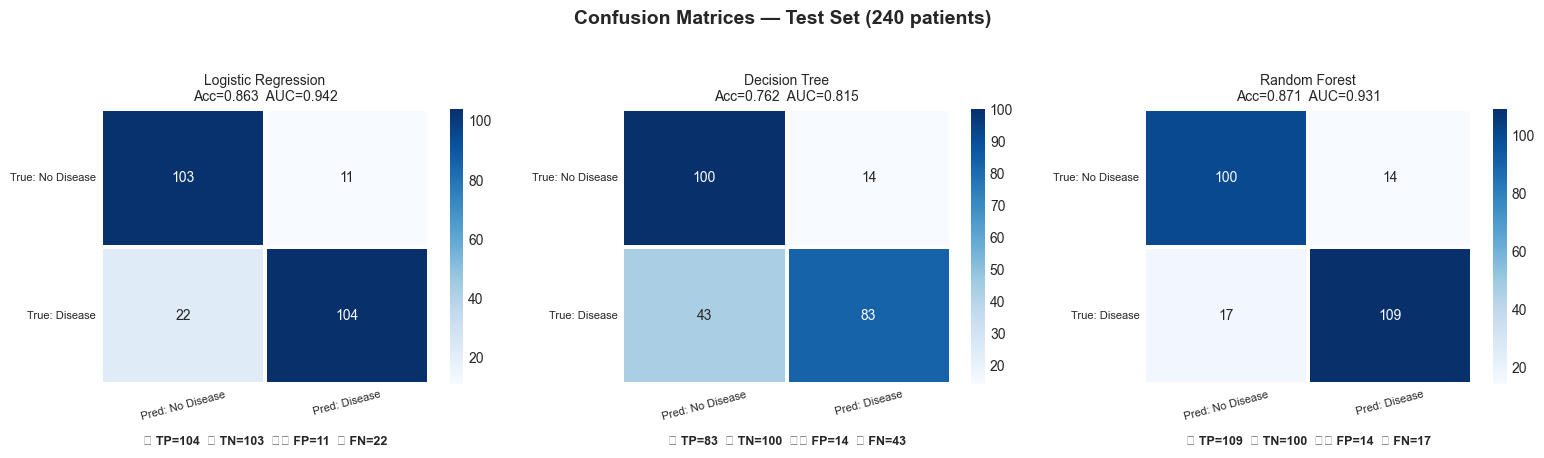

💾 Saved: hd_04_confusion_matrices.png

📖 Confusion Matrix Legend:
   ✅ TP (True Positive)  — Model said Disease,  Patient HAS disease    ← correct!
   ✅ TN (True Negative)  — Model said No Disease, Patient is healthy   ← correct!
   ⚠️  FP (False Positive) — Model said Disease,  Patient is healthy    ← false alarm
   🚨 FN (False Negative) — Model said No Disease, Patient HAS disease  ← DANGEROUS!


In [ ]:
# 1. Create 3 plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — Test Set (240 patients)', fontsize=14, fontweight='bold')

names = list(results.keys()); cols_m = ['#3498db','#2ecc71','#e74c3c']

 # 2. Loop through models - Logistic, Tree, Forest
for ax, name in zip(axes, names):
    # 3. Confusion matrix extract
    cm = results[name]['cm']
    tn,fp,fn,tp = cm.ravel()
    # 4. Heatmap plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=1.5, linecolor='white',
                xticklabels=['Pred: No Disease','Pred: Disease'],
                yticklabels=['True: No Disease','True: Disease'])
    ax.set_title(f'{name}\nAcc={results[name]["acc"]:.3f}  AUC={results[name]["auc"]:.3f}',
                 fontsize=10)
    # 5. Labels
    ax.tick_params(axis='x', labelsize=8, rotation=15)
    ax.tick_params(axis='y', labelsize=8, rotation=0)

# Type	    Meaning
# TP 132	Disease correctly found
# TN 90	    Healthy correctly found
# FP 10	    False alarm
# FN 8	    Missed disease 🚨

    ax.text(0.5, -0.22,
            f'✅ TP={tp}  ✅ TN={tn}  ⚠️ FP={fp}  🚨 FN={fn}',
            transform=ax.transAxes, ha='center', fontsize=9, fontweight='bold')

plt.tight_layout(pad=2)
plt.savefig('hd_04_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hd_04_confusion_matrices.png')

# Explain what each cell means
print()
print('📖 Confusion Matrix Legend:')
print('   ✅ TP (True Positive)  — Model said Disease,  Patient HAS disease    ← correct!')
print('   ✅ TN (True Negative)  — Model said No Disease, Patient is healthy   ← correct!')
print('   ⚠️  FP (False Positive) — Model said Disease,  Patient is healthy    ← false alarm')
print('   🚨 FN (False Negative) — Model said No Disease, Patient HAS disease  ← DANGEROUS!')

---
## Step 8: ROC Curves & Precision-Recall Curves

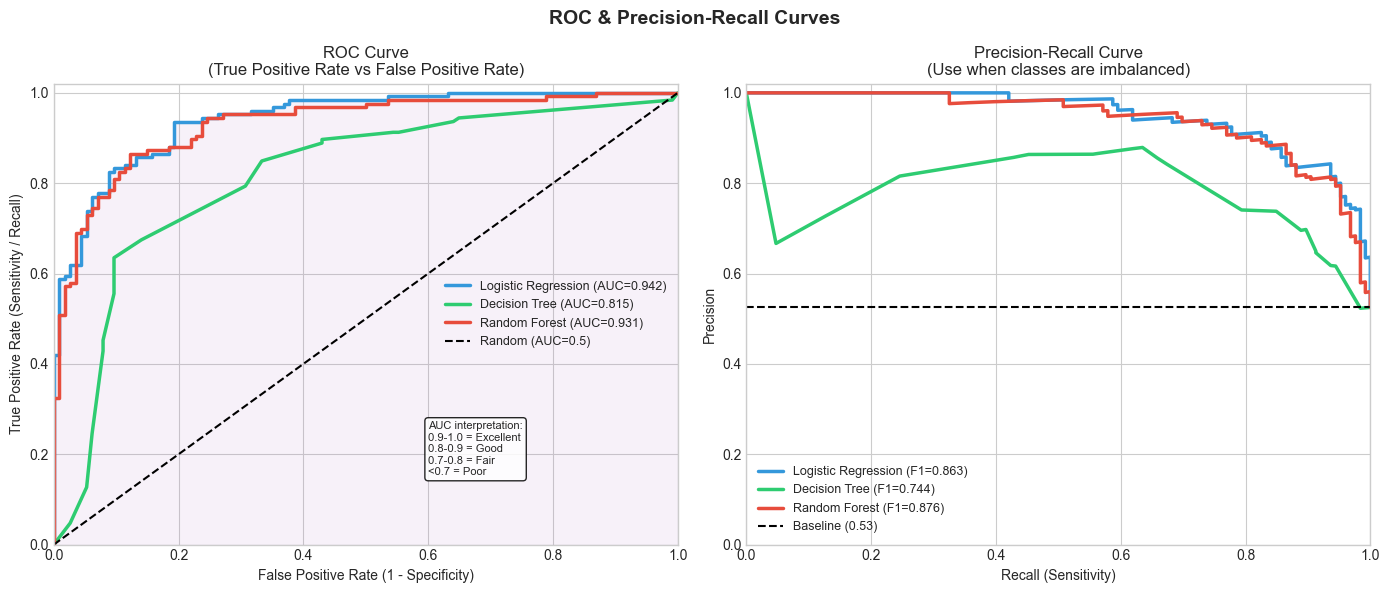

💾 Saved: hd_05_roc_pr_curves.png


In [ ]:
# ROC = Receiver Operating Characteristic
cols_roc = ['#3498db','#2ecc71','#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC & Precision-Recall Curves', fontsize=14, fontweight='bold')

for name, c in zip(names, cols_roc):
    r = results[name]
    axes[0].plot(r['fpr'], r['tpr'], lw=2.5, color=c,
                 label=f'{name} (AUC={r["auc"]:.3f})')
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, r['prob'])
    axes[1].plot(rec_arr, prec_arr, lw=2.5, color=c,
                 label=f'{name} (F1={r["f1"]:.3f})')


axes[0].plot([0,1],[0,1],'k--',lw=1.5,label='Random (AUC=0.5)')
axes[0].fill_between(results[best_name]['fpr'], results[best_name]['tpr'],
                     alpha=0.08, color='#9b59b6')
axes[0].set_title('ROC Curve\n(True Positive Rate vs False Positive Rate)')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[0].legend(fontsize=9); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.02)

axes[0].text(0.6, 0.15,
             'AUC interpretation:\n0.9-1.0 = Excellent\n0.8-0.9 = Good\n0.7-0.8 = Fair\n<0.7 = Poor',
             transform=axes[0].transAxes, fontsize=8,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', ls='--', lw=1.5, label=f'Baseline ({baseline:.2f})')
axes[1].set_title('Precision-Recall Curve\n(Use when classes are imbalanced)')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1.02)

plt.tight_layout()
plt.savefig('hd_05_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hd_05_roc_pr_curves.png')



---
## Step 9: Feature Importance & Decision Tree Visualisation

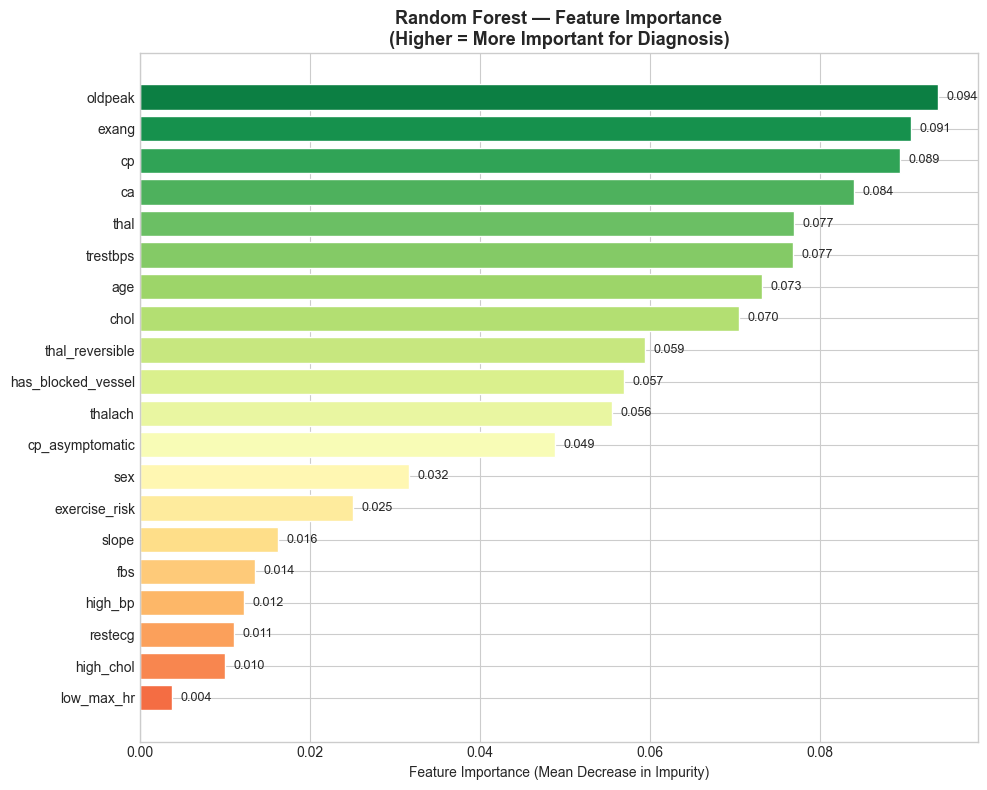

💾 Saved: hd_06_feature_importance.png

🔬 Top 5 most important diagnostic features:
   oldpeak                importance=0.0939
   exang                  importance=0.0908
   cp                     importance=0.0894
   ca                     importance=0.0840
   thal                   importance=0.0770


In [ ]:

rf_model = models['Random Forest'].named_steps['model']
feat_imp  = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.95, len(feat_imp)))

plt.figure(figsize=(10, 8))
bars = plt.barh(feat_imp.index, feat_imp.values, color=colors_fi, edgecolor='white')
plt.title('Random Forest — Feature Importance\n(Higher = More Important for Diagnosis)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
for bar, v in zip(bars, feat_imp.values):
    plt.text(v+0.001, bar.get_y()+bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('hd_06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hd_06_feature_importance.png')

print('\n🔬 Top 5 most important diagnostic features:')
for feat, val in feat_imp.sort_values(ascending=False).head(5).items():
    print(f'   {feat:<22} importance={val:.4f}')

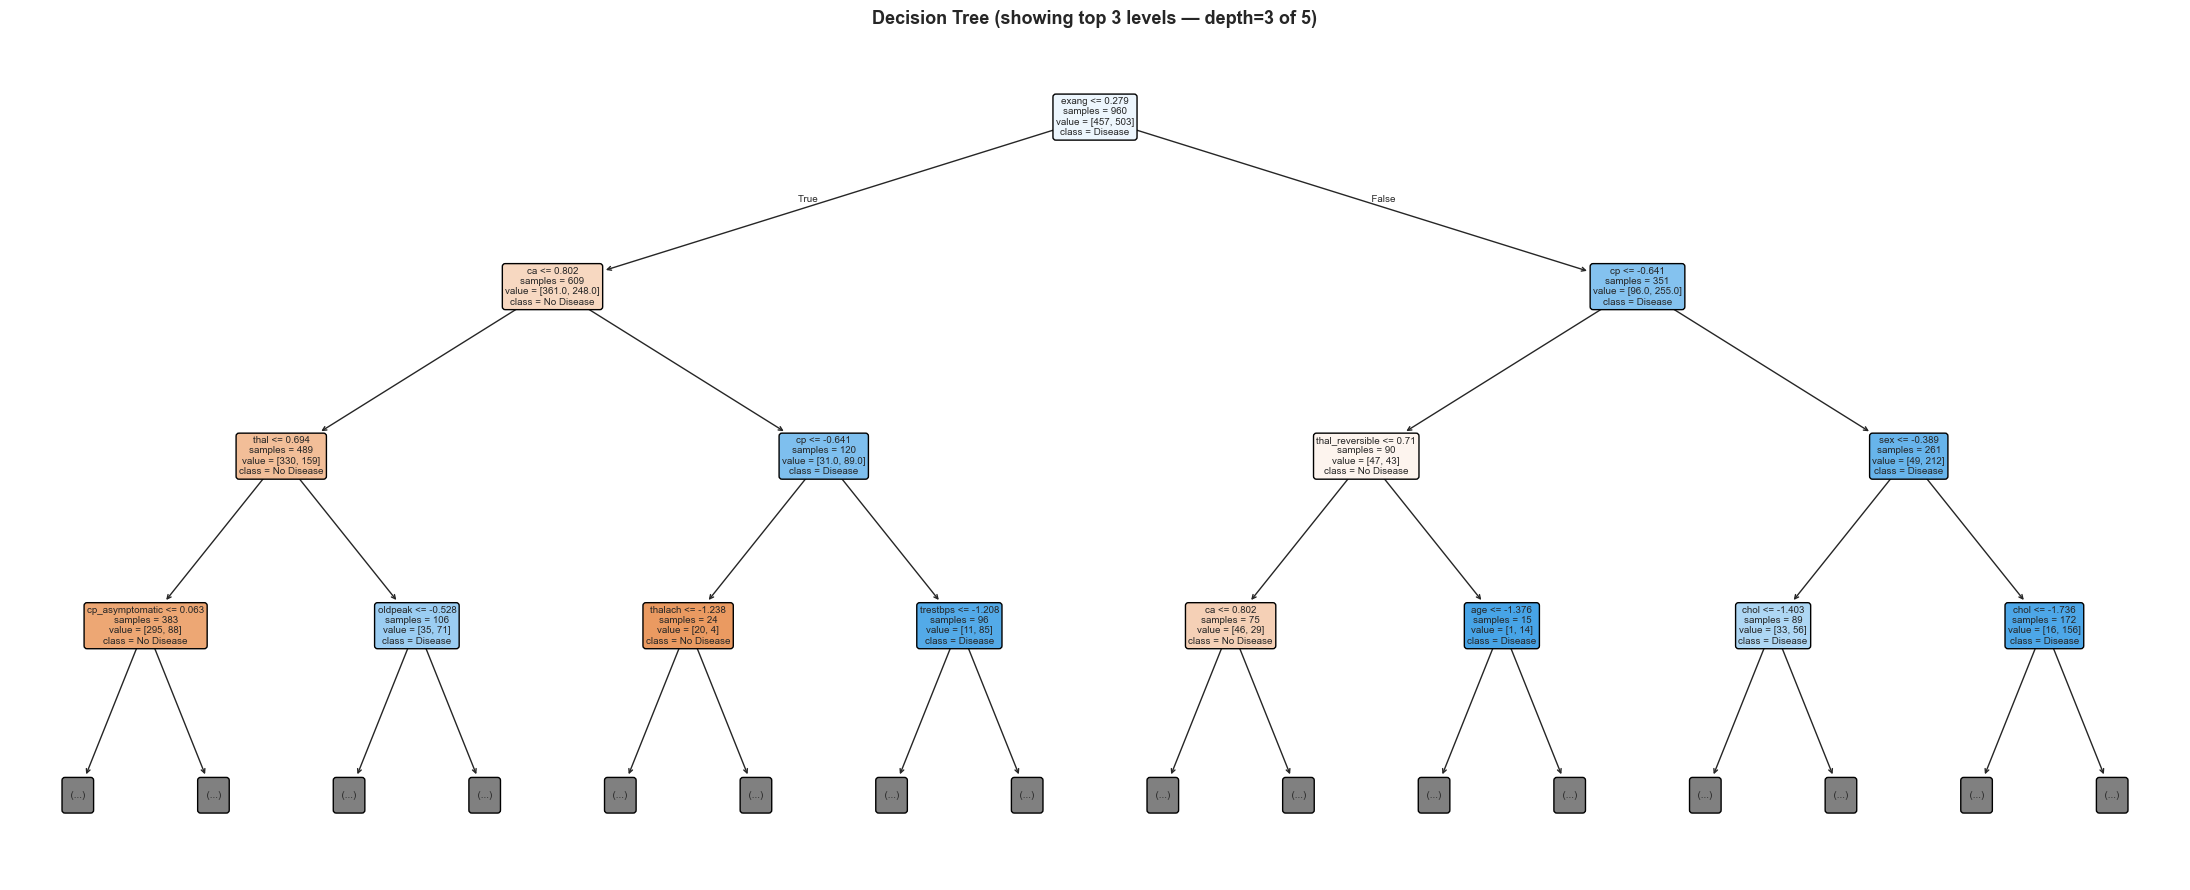

💾 Saved: hd_07_decision_tree.png

💡 Read the tree: at each node, TRUE goes LEFT, FALSE goes RIGHT
   Blue nodes = majority No Disease  |  Orange nodes = majority Disease


In [ ]:

# Visualise the Decision Tree (shallow view)
dt_model = models['Decision Tree'].named_steps['model']
fig, ax  = plt.subplots(figsize=(22, 9))
plot_tree(dt_model, feature_names=FEATURES,
          class_names=['No Disease','Disease'],
          filled=True, rounded=True, fontsize=7,
          ax=ax, max_depth=3, impurity=False)
plt.title('Decision Tree (showing top 3 levels — depth=3 of 5)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hd_07_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hd_07_decision_tree.png')
print('\n💡 Read the tree: at each node, TRUE goes LEFT, FALSE goes RIGHT')
print('   Blue nodes = majority No Disease  |  Orange nodes = majority Disease')


---
## Step 10: Threshold Tuning



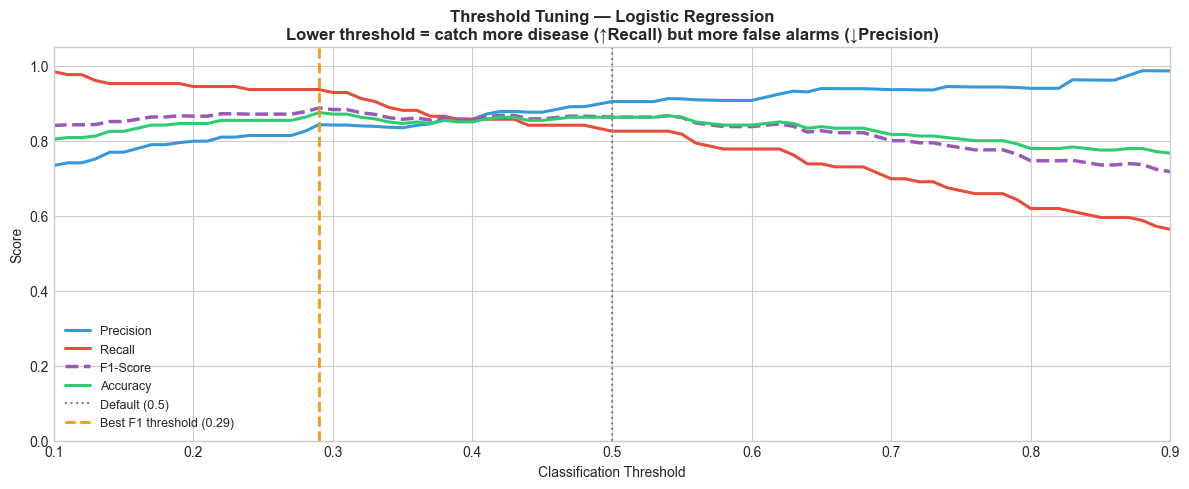

📊 Threshold Comparison — Logistic Regression:

  Default (0.5):
    Accuracy  = 0.863
    Precision = 0.904
    Recall    = 0.825  ← most important in medical!
    F1-Score  = 0.863

  Optimal (0.29):
    Accuracy  = 0.875
    Precision = 0.843
    Recall    = 0.937  ← most important in medical!
    F1-Score  = 0.887


In [ ]:
# 1. Get probabilities
best_prob = results[best_name]['prob']
# 2. Create thresholds meaning - 0.10 to 0.94
thresholds = np.arange(0.1, 0.95, 0.01)
t_prec=[]; t_rec=[]; t_f1=[]; t_acc=[]

# 3. Loop through thresholds
for t in thresholds:


# 4. Convert probability → prediction
    pred_t = (best_prob >= t).astype(int)
    # 5. Calculate Metrics
    t_prec.append(precision_score(y_test, pred_t, zero_division=0))
    t_rec.append(recall_score(y_test, pred_t, zero_division=0))
    t_f1.append(f1_score(y_test, pred_t, zero_division=0))
    t_acc.append(accuracy_score(y_test, pred_t))
# 6. Best Threshold 
best_t = thresholds[np.argmax(t_f1)]

plt.figure(figsize=(12, 5))
plt.plot(thresholds, t_prec, lw=2.2, color='#3498db', label='Precision') # 👉 threshold increase → precision increase
plt.plot(thresholds, t_rec,  lw=2.2, color='#e74c3c', label='Recall') #👉 threshold decrease → recall increase
plt.plot(thresholds, t_f1,   lw=2.5, color='#9b59b6', label='F1-Score', ls='--') # 👉 best balance point
plt.plot(thresholds, t_acc,  lw=2.2, color='#2ecc71', label='Accuracy') #👉 overall correctness
plt.axvline(0.5, color='grey', ls=':', lw=1.5, label='Default (0.5)') # 👉 default threshold
plt.axvline(best_t, color='#f39c12', ls='--', lw=2,
            label=f'Best F1 threshold ({best_t:.2f})') #👉 optimal threshold
plt.title(f'Threshold Tuning — {best_name}\nLower threshold = catch more disease (↑Recall) but more false alarms (↓Precision)',
          fontsize=12, fontweight='bold')
plt.xlabel('Classification Threshold')
plt.ylabel('Score'); plt.legend(fontsize=9)
plt.xlim(0.1, 0.9); plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('hd_08_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare metrics at default vs optimal threshold
print(f'📊 Threshold Comparison — {best_name}:')
for t, label in [(0.5, 'Default (0.5)'), (best_t, f'Optimal ({best_t:.2f})')]:
    pred_t = (best_prob >= t).astype(int)
    print(f'\n  {label}:')
    print(f'    Accuracy  = {accuracy_score(y_test, pred_t):.3f}')
    print(f'    Precision = {precision_score(y_test, pred_t):.3f}')
    print(f'    Recall    = {recall_score(y_test, pred_t):.3f}  ← most important in medical!')
    print(f'    F1-Score  = {f1_score(y_test, pred_t):.3f}')

---
## Step 11: Predict for a New Patient

In [21]:
def predict_heart_disease(age, sex, cp, trestbps, chol, fbs, restecg,
                           thalach, exang, oldpeak, slope, ca, thal,
                           threshold=0.5, model_name=None):
    """
    Predict heart disease risk for a new patient.

    Parameters match the dataset columns. Returns probability and prediction.

    Example:
        predict_heart_disease(age=57, sex=1, cp=2, trestbps=140, chol=241,
                              fbs=0, restecg=1, thalach=123, exang=1,
                              oldpeak=0.2, slope=1, ca=0, thal=3)
    """
    if model_name is None: model_name = best_name

    # Engineered features
    high_bp = int(trestbps > 140)
    high_chol = int((chol or 246) > 240)
    cp_asymptomatic = int(cp == 3)
    exercise_risk = int(exang) * int(oldpeak > 1)
    low_max_hr = int(thalach < 120)
    thal_reversible = int((thal or 0) == 3)
    has_blocked = int((ca or 0) > 0)

    sample = pd.DataFrame([{
        'age':age,'sex':sex,'cp':cp,'trestbps':trestbps,'chol':chol,
        'fbs':fbs,'restecg':restecg,'thalach':thalach,'exang':exang,
        'oldpeak':oldpeak,'slope':slope,'ca':ca,'thal':thal,
        'high_bp':high_bp,'high_chol':high_chol,
        'cp_asymptomatic':cp_asymptomatic,'exercise_risk':exercise_risk,
        'low_max_hr':low_max_hr,'thal_reversible':thal_reversible,
        'has_blocked_vessel':has_blocked
    }])

    prob = models[model_name].predict_proba(sample)[0,1]
    pred = int(prob >= threshold)

    risk_label = (
        '🔴 HIGH RISK' if prob >= 0.75 else
        '🟡 MODERATE RISK' if prob >= 0.5 else
        '🟢 LOW RISK'
    )

    print('━'*52)
    print('  ❤️  HEART DISEASE RISK PREDICTION')
    print('━'*52)
    print(f'  Age       : {age} yrs  |  Sex: {"Male" if sex else "Female"}')
    print(f'  Chest Pain: Type {cp} ({["Typical Angina","Atypical","Non-Anginal","Asymptomatic"][cp]})')
    print(f'  BP        : {trestbps} mmHg  |  Cholesterol: {chol}')
    print(f'  Max HR    : {thalach}  |  Exercise Angina: {"Yes" if exang else "No"}')
    print(f'  ST Depress: {oldpeak}  |  CA vessels: {ca}')
    print('━'*52)
    print(f'  Model     : {model_name}')
    print(f'  Probability: {prob*100:.1f}% chance of heart disease')
    print(f'  Prediction : {risk_label}')
    print('━'*52)
    print('  ⚕️  DISCLAIMER: This is an ML demo, NOT medical advice.')
    print('      Please consult a cardiologist for actual diagnosis.')
    return prob, pred


# Test cases
print('=== PATIENT 1: High-risk profile ===')
p1 = predict_heart_disease(
    age=62, sex=1, cp=3, trestbps=155, chol=290,
    fbs=1, restecg=1, thalach=105, exang=1,
    oldpeak=2.6, slope=1, ca=2, thal=3
)

print('\n=== PATIENT 2: Low-risk profile ===')
p2 = predict_heart_disease(
    age=38, sex=0, cp=1, trestbps=118, chol=210,
    fbs=0, restecg=0, thalach=172, exang=0,
    oldpeak=0.1, slope=2, ca=0, thal=2
)

=== PATIENT 1: High-risk profile ===
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❤️  HEART DISEASE RISK PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Age       : 62 yrs  |  Sex: Male
  Chest Pain: Type 3 (Asymptomatic)
  BP        : 155 mmHg  |  Cholesterol: 290
  Max HR    : 105  |  Exercise Angina: Yes
  ST Depress: 2.6  |  CA vessels: 2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model     : Logistic Regression
  Probability: 100.0% chance of heart disease
  Prediction : 🔴 HIGH RISK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⚕️  DISCLAIMER: This is an ML demo, NOT medical advice.
      Please consult a cardiologist for actual diagnosis.

=== PATIENT 2: Low-risk profile ===
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❤️  HEART DISEASE RISK PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Age       : 38 yrs  |  Sex: Female
  Chest Pain: Type 1 (Atypical)
  BP        : 118 mmHg  |  Cholesterol: 210
  Max 

In [22]:
df_model.to_csv('final_heart_disease_detector.csv', index=False)

print('✅ Final CSV saved')

✅ Final CSV saved



**GitHub README:**
- Embed `hd_04_confusion_matrices.png` — shows you understand medical implications of FN vs FP
- Embed `hd_05_roc_pr_curves.png` — shows ROC-AUC understanding
- Embed `hd_07_decision_tree.png` — visually impressive and interpretable
- Table: model comparison with all 5 metrics
